In [1]:
import numpy as np
import sympy as sy
import matplotlib.cm as cm
import matplotlib.pylab as plt
from PIL import Image
import warnings
import time
import os

warnings.filterwarnings('ignore')  
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 20
plt.rcParams['legend.fontsize'] = 30
from IPython.display import  display, clear_output, Math

## $$\text{Cat Map : Arnold Diffusion}$$

$\qquad \begin{align} x_{n+1} &= (x_n + y_n)  \\ y_{n+1} &= (x_n + 2y_n)  \end{align} \mod 1$

In [2]:
def arnold_cat_map_discrete(u, v, size, matrix):
    coords = np.array([u, v])
    transformed_coords = np.dot(matrix, coords) % size
    return transformed_coords[0], transformed_coords[1]

def apply_transformation_discrete(image, num_iterations, matrix):
    width, height = image.size
    pixels = np.array(image)
    size = width           # Assuming width == height for a square image
    transformed_image = np.zeros_like(pixels)
    for _ in range(num_iterations):
        new_pixels = np.zeros_like(pixels)
        for i in range(width):
            for j in range(height):
                u, v = i, j
                u_new, v_new = arnold_cat_map_discrete(u, v, size, matrix)
                new_pixels[v_new, u_new] = pixels[j, i]
        pixels = new_pixels
        transformed_image = pixels
    return transformed_image

$\qquad C = \begin{bmatrix} 1 &  1  \\ 1 & 2 \end{bmatrix}$

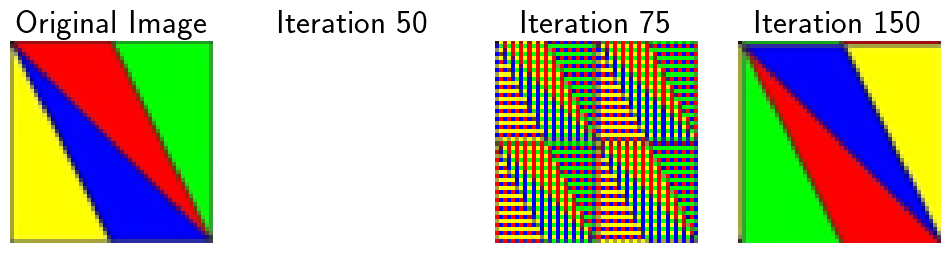

In [3]:
image_path = 'square.png'
image = Image.open(image_path)  
image = image.resize((50, 50))               # Resize to 50x50 if needed
iterations = [0, 50, 75, 150]
matrix = np.array([[1, 1], [1, 2]])
transformed_images = [apply_transformation_discrete(image, i, matrix) for i in iterations]

fig, axs = plt.subplots(1, 4, figsize=(12, 12))
axs = axs.flatten()  
axs[0].imshow(np.array(image))
axs[0].set_title('Original Image')
axs[0].axis('off')

for i, iteration in enumerate(iterations[1:]):
    axs[i+1].imshow(transformed_images[i])
    axs[i+1].set_title(f'Iteration {iteration}')
    axs[i+1].axis('off')
plt.show()

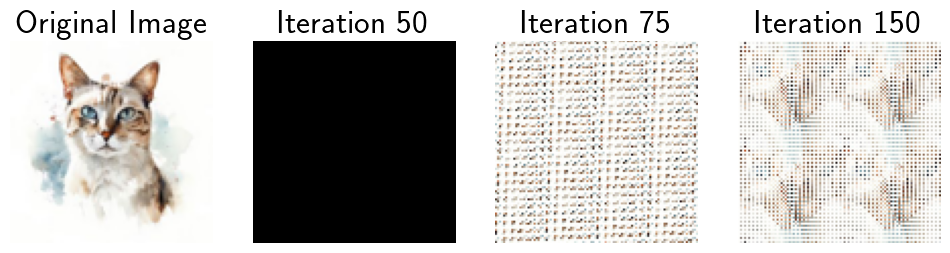

In [4]:
image_path = 'cat.jpg'
image = Image.open(image_path)  
image = image.resize((100, 100))               # Resize to 50x50 if needed
iterations = [0, 50, 75, 150]
matrix = np.array([[1, 1], [1, 2]])
transformed_images = [apply_transformation_discrete(image, i, matrix) for i in iterations]

fig, axs = plt.subplots(1, 4, figsize=(12, 12))
axs = axs.flatten()  
axs[0].imshow(np.array(image))
axs[0].set_title('Original Image')
axs[0].axis('off')

for i, iteration in enumerate(iterations[1:]):
    axs[i+1].imshow(transformed_images[i])
    axs[i+1].set_title(f'Iteration {iteration}')
    axs[i+1].axis('off')
plt.show()

$\qquad C = \begin{bmatrix} 2 & 1 \\ 1 & 1 \end{bmatrix}$

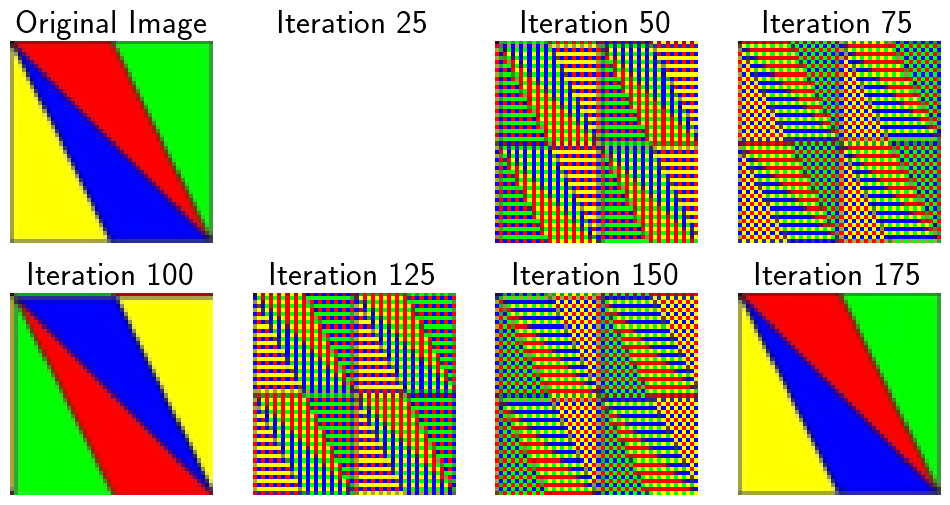

In [5]:
image_path = 'square.png'
image = Image.open(image_path)
image = image.resize((50, 50))               # Resize to 50x50 if needed
iterations = [0, 25, 50, 75, 100, 125, 150, 175]
matrix = np.array([[2, 1], [1, 1]])
transformed_images = [apply_transformation_discrete(image, i, matrix) for i in iterations]

fig, axs = plt.subplots(2, 4, figsize=(12, 6))
axs = axs.flatten()  
axs[0].imshow(np.array(image))
axs[0].set_title('Original Image')
axs[0].axis('off')

for i, iteration in enumerate(iterations[1:]):
    axs[i+1].imshow(transformed_images[i])
    axs[i+1].set_title(f'Iteration {iteration}')
    axs[i+1].axis('off')
plt.show()

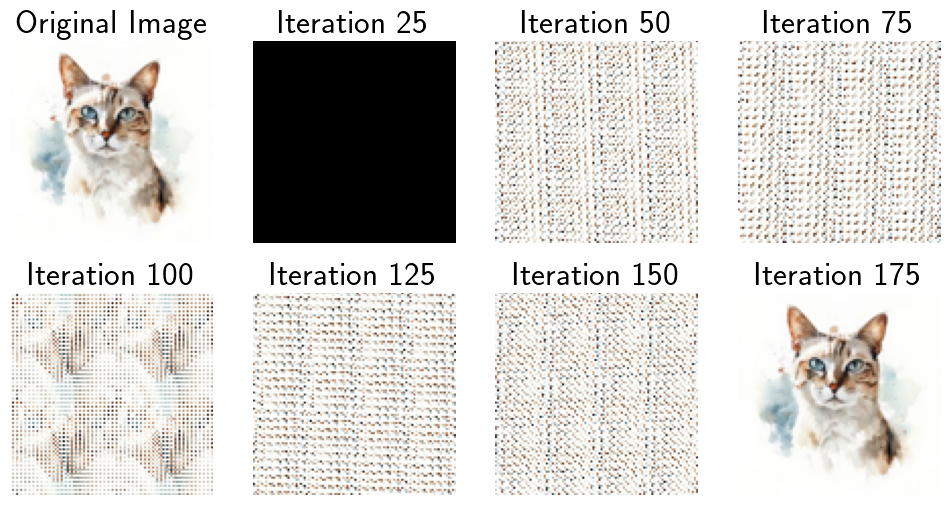

In [6]:
image_path = 'cat.jpg'
image = Image.open(image_path)
image = image.resize((100, 100))               # Resize to 50x50 if needed
iterations = [0, 25, 50, 75, 100, 125, 150, 175]
matrix = np.array([[2, 1], [1, 1]])
transformed_images = [apply_transformation_discrete(image, i, matrix) for i in iterations]

fig, axs = plt.subplots(2, 4, figsize=(12, 6))
axs = axs.flatten()  
axs[0].imshow(np.array(image))
axs[0].set_title('Original Image')
axs[0].axis('off')

for i, iteration in enumerate(iterations[1:]):
    axs[i+1].imshow(transformed_images[i])
    axs[i+1].set_title(f'Iteration {iteration}')
    axs[i+1].axis('off')
plt.show()

## $\qquad\qquad\qquad\qquad\qquad\qquad\qquad\text{The Smale horseshoe map}$
Let
$$Q = [-1,1] \times [-1,1] \subset \mathbb{R}^{2}$$ 
be the initial square in phase space. A single iteration of the horseshoe transformation is constructed as the composition of two mappings,
$$H = F \circ L,$$ 
where L is a linear affine deformation and F is a nonlinear folding transformation.
## Linear Stretching
The first stage consists of anisotropic expansion and contraction.                                                                                          
The square is stretched along the horizontal direction while being compressed vertically. The affine transformation is defined as:
$$L(\mathbf{x}) = \mathbf{A}(\mathbf{x}-\mathbf{p}) + \mathbf{p},$$ 
where
$$\mathbf{x} = \begin{pmatrix} x \\ y \end{pmatrix}, \qquad \mathbf{p} = \begin{pmatrix} -1 \\ -1 \end{pmatrix},$$ 
and
$$\mathbf{A} = \begin{pmatrix} 2.5 & 0 \\ 0 & 0.4 \end{pmatrix}.$$ 
Evaluating this system yields the intermediate coordinate expressions:
$$\begin{aligned} x' &= 2.5(x+1) - 1, \\ y' &= 0.4(y+1) - 1. \end{aligned}$$ 
The determinant of the transformation matrix is:
$$\det(\mathbf A) = 2.5 \times 0.4 = 1,$$ 
which proves that the mapping is strictly area-preserving while producing exponential expansion along one principal direction and contraction along the other.
## Nonlinear Folding
The elongated strip cannot remain unbounded within physical phase space and must be folded back into the original neighborhood.                          
The folding map **F** is defined piecewise according to the stretched horizontal coordinate domains.                                                           
For the regional band $1 ≤ x' < 2$, a semicircular rotation parameter is introduced:
$$\theta = \pi(x'-1),$$ 
yielding the nonlinear transformation:
$$\begin{aligned} x'' &= 1 - y'\sin\theta, \\ y'' &= y'\cos\theta. \end{aligned}$$ 
This coordinate assignment smoothly bends the stretched strip through an angular trajectory varying continuously across $0 ≤ θ ≤ π$.                              
For the terminal overflow region x' ≥ 2, the remaining portion undergoes a rigid 180° inversion coupled with a translation shift:
$$\begin{aligned} x'' &= 3 - x', \\ y'' &= -y'. \end{aligned}$$ 
Consequently, the complete non-linear folding function F(x', y') is expressed as:
$$F(x',y') = \begin{cases} (x',y'), & x' < 1, \\ \left(1 - y'\sin\theta, \, y'\cos\theta\right), & 1 \le x' < 2, \\ (3 - x', -y'), & x' \ge 2. \end{cases}$$ 
## Horseshoe Transformation
The complete forward transformation map is the composite system:
$$H(x,y) = F\left(L(x,y)\right).$$ 
Repeated discrete applications produce the trajectory sequence:
$$(x_n,y_n) = H^n(x_0,y_0),$$ 
where $H^n$ denotes the n-th iteration layer:
$$H^n = \underbrace{H \circ H \circ \cdots \circ H}_{n \text{ times}}.$$ 
Each forward iteration step stretches trajectories exponentially along the unstable manifold, contracts them along the stable manifold,                         
and folds the resulting strip back into the bounded domain Q.                                                                                             
This structural recurrence isolates the invariant Cantor set attractor $\Lambda$,                                                                     
generating key topological signatures of chaos including sensitive dependence on initial conditions,                                                    
structural mixing, and an infinite set of unstable periodic orbits.



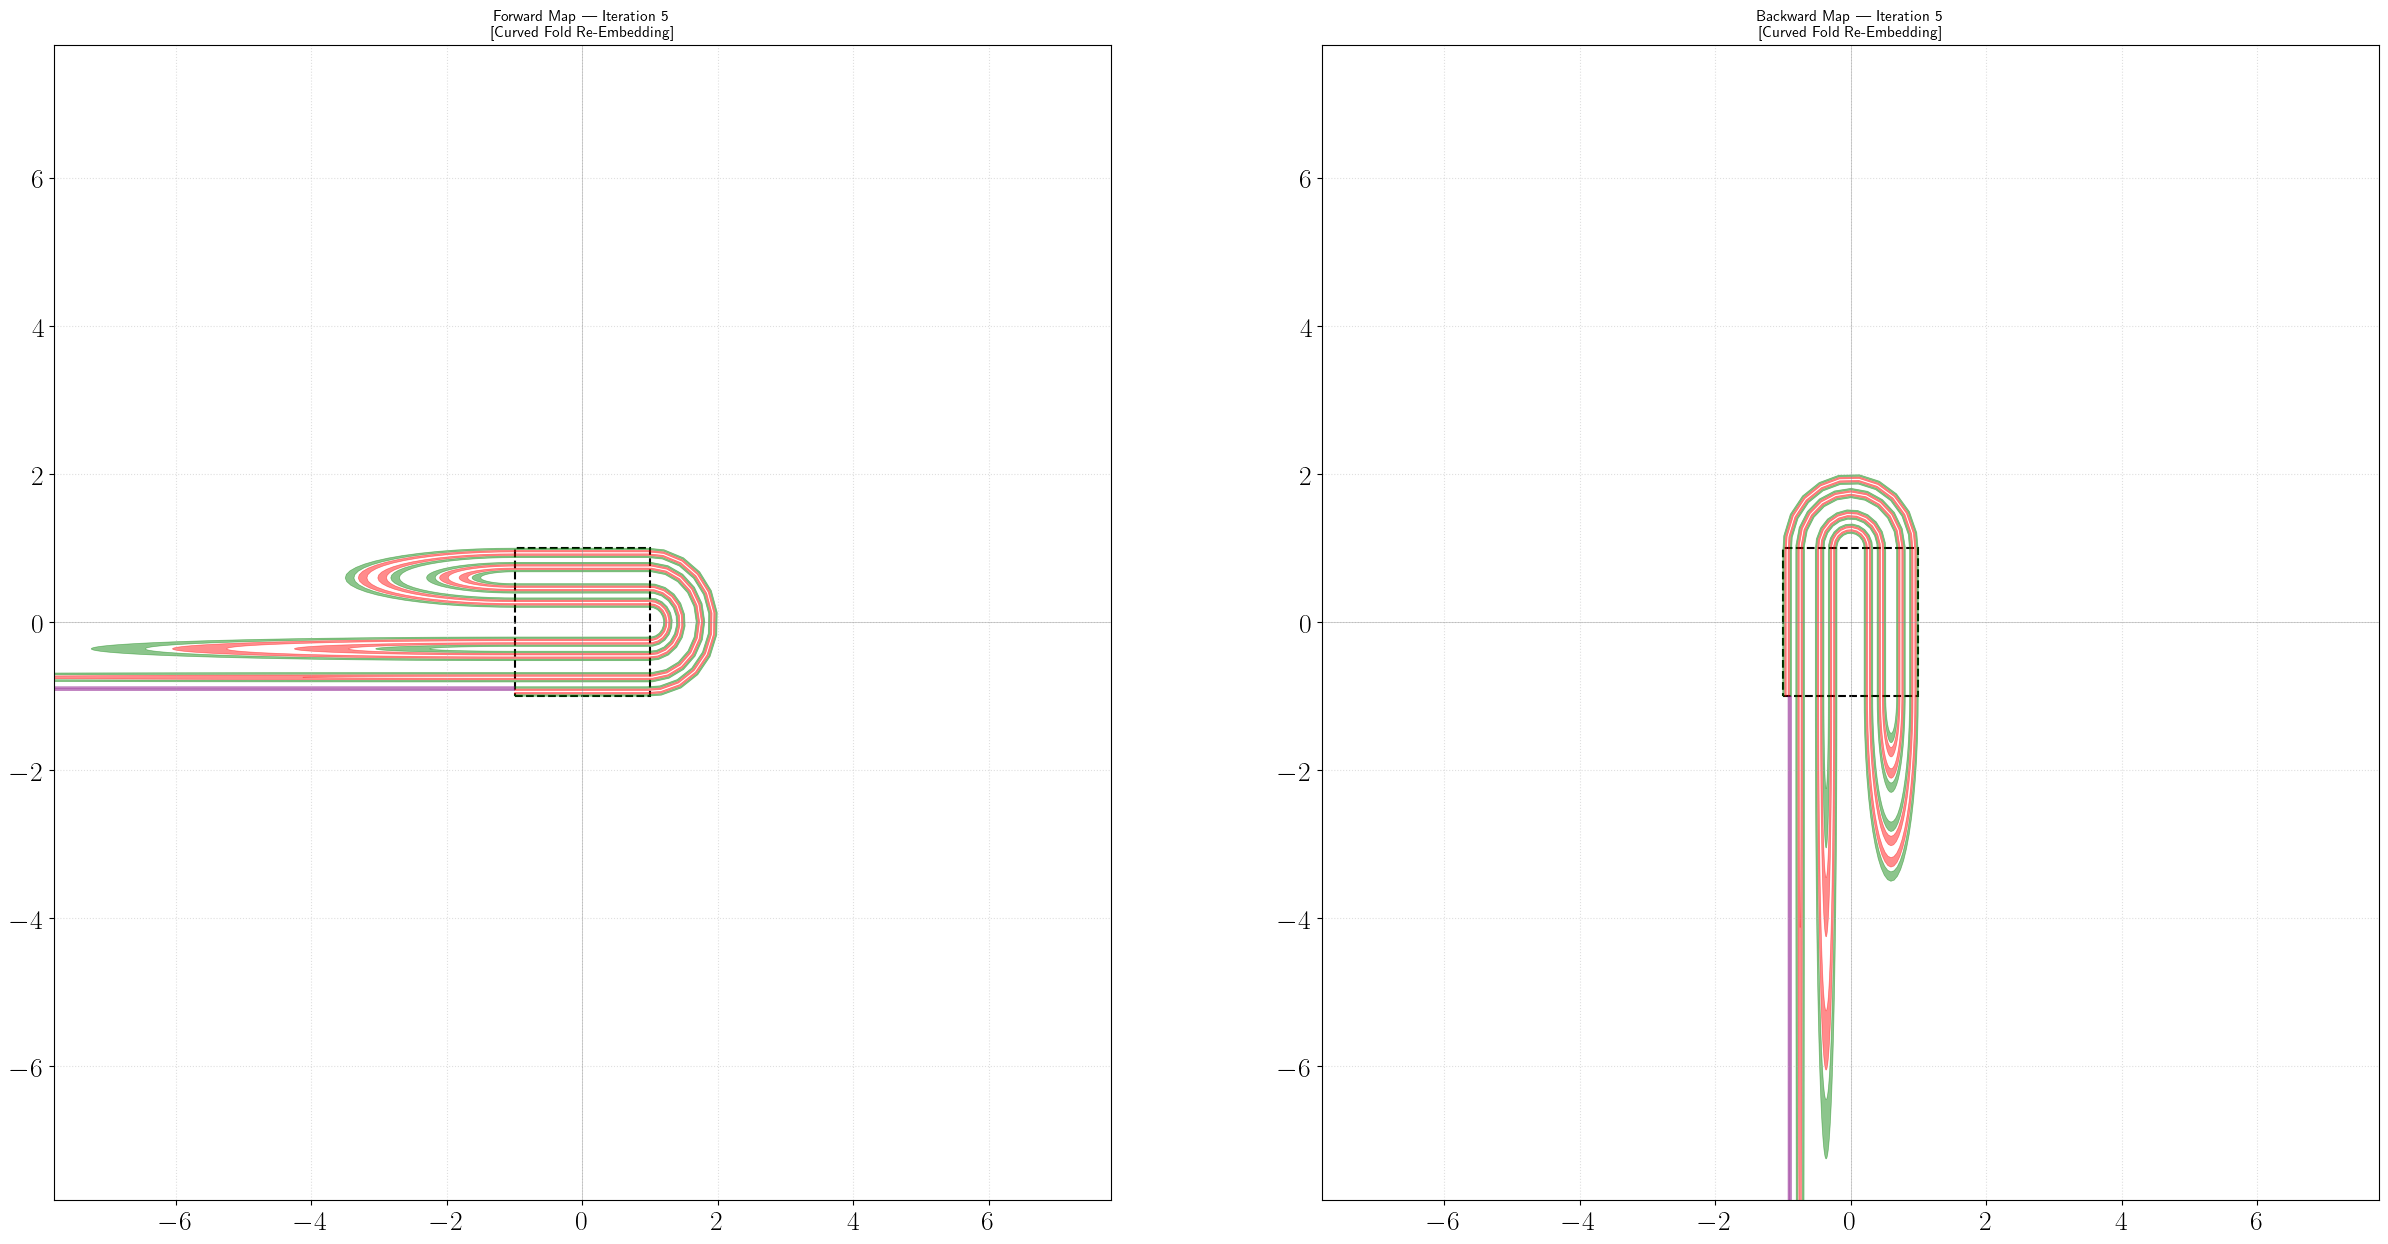

In [2]:
def create_points(a, b, c, d, n=800):
    side1 = np.linspace(a, b, n)
    side2 = np.linspace(b, c, n)
    side3 = np.linspace(c, d, n)
    side4 = np.linspace(d, a, n)
    pts = np.vstack([side1, side2, side3, side4])
    return pts[:, 0], pts[:, 1]

def apply_linear_stretch(x, y, matrix, about_point=None):
    if about_point is None:
        about_point = np.array([-1.0, -1.0])
    x_shifted = x - about_point[0]
    y_shifted = y - about_point[1]
    x_new = matrix[0][0] * x_shifted + matrix[0][1] * y_shifted + about_point[0]
    y_new = matrix[1][0] * x_shifted + matrix[1][1] * y_shifted + about_point[1]
    return x_new, y_new

def f_map_to_circle(x, y):
    x_out, y_out = np.copy(x), np.copy(y)
    mask_circle = (x >= 1.0) & (x < 2.0)      # Semicircular bending zone [1, 2)
    x_c = x[mask_circle] - 1.0
    x_out[mask_circle] = (-np.sin(np.pi * x_c) * y[mask_circle]) + 1.0
    y_out[mask_circle] = np.cos(np.pi * x_c) * y[mask_circle]
    mask_trans = x >= 2.0                        # Linear translation and 180 flip zone [2, infinity)
    x_out[mask_trans] = (-x[mask_trans]) + 3.0
    y_out[mask_trans] = -y[mask_trans]  
    return x_out, y_out

def b_map_to_circle(x, y):
    x_out, y_out = np.copy(x), np.copy(y)
    y_inv, x_inv = np.copy(x), np.copy(y) # Swapped to reuse core logic
    
    mask_circle = (x_inv >= 1.0) & (x_inv < 2.0)
    x_c = x_inv[mask_circle] - 1.0
    y_out[mask_circle] = (-np.sin(np.pi * x_c) * y_inv[mask_circle]) + 1.0
    x_out[mask_circle] = np.cos(np.pi * x_c) * y_inv[mask_circle]
    
    mask_trans = x_inv >= 2.0
    y_out[mask_trans] = (-x_inv[mask_trans]) + 3.0
    x_out[mask_trans] = -y_inv[mask_trans]
    
    return x_out, y_out

def execute_full_forward_step(strips):
    f_matrix = [[2.5, 0.0], [0.0, 0.4]]
    anchor = np.array([-1.0, -1.0])
    next_generation = []
    for x, y, color in strips:
        sx, sy = apply_linear_stretch(x, y, f_matrix, about_point=anchor)
        fx, fy = f_map_to_circle(sx, sy)
        next_generation.append([fx, fy, color])
    return next_generation

def execute_full_backward_step(strips):
    b_matrix = [[0.4, 0.0], [0.0, 2.5]]
    anchor = np.array([-1.0, -1.0])
    next_generation = []
    for x, y, color in strips:
        sx, sy = apply_linear_stretch(x, y, b_matrix, about_point=anchor)
        bx, by = b_map_to_circle(sx, sy)
        next_generation.append([bx, by, color])
    return next_generation

def plot_multistep_canvas(f_strips, b_strips, iteration_num, sub_step_name):
    fig, axes = plt.subplots(1, 2, figsize=(30, 15))
    
    for ax in axes:
        ax.set_xlim(-7.8, 7.8)
        ax.set_ylim(-7.8, 7.8)
        ax.grid(True, linestyle=':', alpha=0.4)
        ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
        ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)      
        ax.add_patch(plt.Rectangle((-1, -1), 2, 2, edgecolor='black', facecolor='none', lw=1.5, ls='--'))

    axes[0].set_title(f"Forward Map — Iteration {iteration_num}\n[{sub_step_name}]", fontsize=11, fontweight='bold')
    for x, y, color in f_strips:
        axes[0].fill(x, y, color=color, alpha=0.45, edgecolor=color, lw=0.5)
        
    axes[1].set_title(f"Backward Map — Iteration {iteration_num}\n[{sub_step_name}]", fontsize=11, fontweight='bold')
    for x, y, color in b_strips:
        axes[1].fill(x, y, color=color, alpha=0.45, edgecolor=color, lw=0.5)
        
    plt.show()

def run_deep_iterations(max_iterations=3):
    fx1, fy1 = create_points([-1, 1], [-0.2, 1], [-0.2, -1], [-1, -1])
    fx2, fy2 = create_points([0.2, 1], [1, 1], [1, -1], [0.2, -1])
    fx3, fy3 = create_points([-0.2, 1], [0.2, 1], [0.2, -1], [-0.2, -1])
    f_current = [[fx1, fy1, 'green'], [fx2, fy2, 'red'], [fx3, fy3, 'purple']]    
    bx1, by1 = create_points([1, -1], [1, -0.2], [-1, -0.2], [-1, -1])
    bx2, by2 = create_points([1, 1], [1, 0.2], [-1, 0.2], [-1, 1])
    bx3, by3 = create_points([1, -0.2], [1, 0.2], [-1, 0.2], [-1, -0.2])
    b_current = [[bx1, by1, 'green'], [bx2, by2, 'red'], [bx3, by3, 'purple']]
    clear_output(wait=True)
    plot_multistep_canvas(f_current, b_current, iteration_num=0, sub_step_name="Initial Base Configuration")
    time.sleep(2.5)
    f_matrix = [[2.5, 0.0], [0.0, 0.4]]
    b_matrix = [[0.4, 0.0], [0.0, 2.5]]
    anchor = np.array([-1.0, -1.0])

    for i in range(1, max_iterations + 1):
        f_stretched = []
        for x, y, color in f_current:
            sx, sy = apply_linear_stretch(x, y, f_matrix, about_point=anchor)
            f_stretched.append([sx, sy, color])
            
        b_stretched = []
        for x, y, color in b_current:
            sx, sy = apply_linear_stretch(x, y, b_matrix, about_point=anchor)
            b_stretched.append([sx, sy, color])
            
        clear_output(wait=True)
        plot_multistep_canvas(f_stretched, b_stretched, iteration_num=i, sub_step_name="Linear Matrix Stretching")
        time.sleep(2.0)
        
        f_current = []
        for x, y, color in f_stretched:
            fx, fy = f_map_to_circle(x, y)
            f_current.append([fx, fy, color])
            
        b_current = []
        for x, y, color in b_stretched:
            bx, by = b_map_to_circle(x, y)
            b_current.append([bx, by, color])
            
        clear_output(wait=True)
        plot_multistep_canvas(f_current, b_current, iteration_num=i, sub_step_name="Curved Fold Re-Embedding")
        time.sleep(2.5)



run_deep_iterations(max_iterations=5)

## $$\text{The Baker's Map}$$ 

$ \qquad \begin{equation*} (x_n, y_n) = \left\{\begin{array}{rl} (2x_n, ay_n) & \text{for } 0\le x_n\le \frac{1}{2},\\ (2x_n-1, ay_n+\frac{1}{2}) & \text{for } \frac{1}{2}\le x_n\le 1.\end{array} \right. \\ \qquad\qquad\text{where } 0<a\le\frac{1}{2} \end{equation*} $ 

In [22]:
def bakers_map(x,y, a):

    if 0 <= x <= 0.5:
        return 2 * x, a * y
    else:
        return 2 * x - 1, a * y + 0.5

In [23]:
def iterate_bakers_map(n, a, points):
    x_vals = [point[0] for point in points]
    y_vals = [point[1] for point in points]
    
    for _ in range(n):
        new_points = []
        for x, y in zip(x_vals, y_vals):
            x_new, y_new = bakers_map(x, y, a)
            new_points.append((x_new, y_new))
        x_vals, y_vals = zip(*new_points)
    return x_vals, y_vals

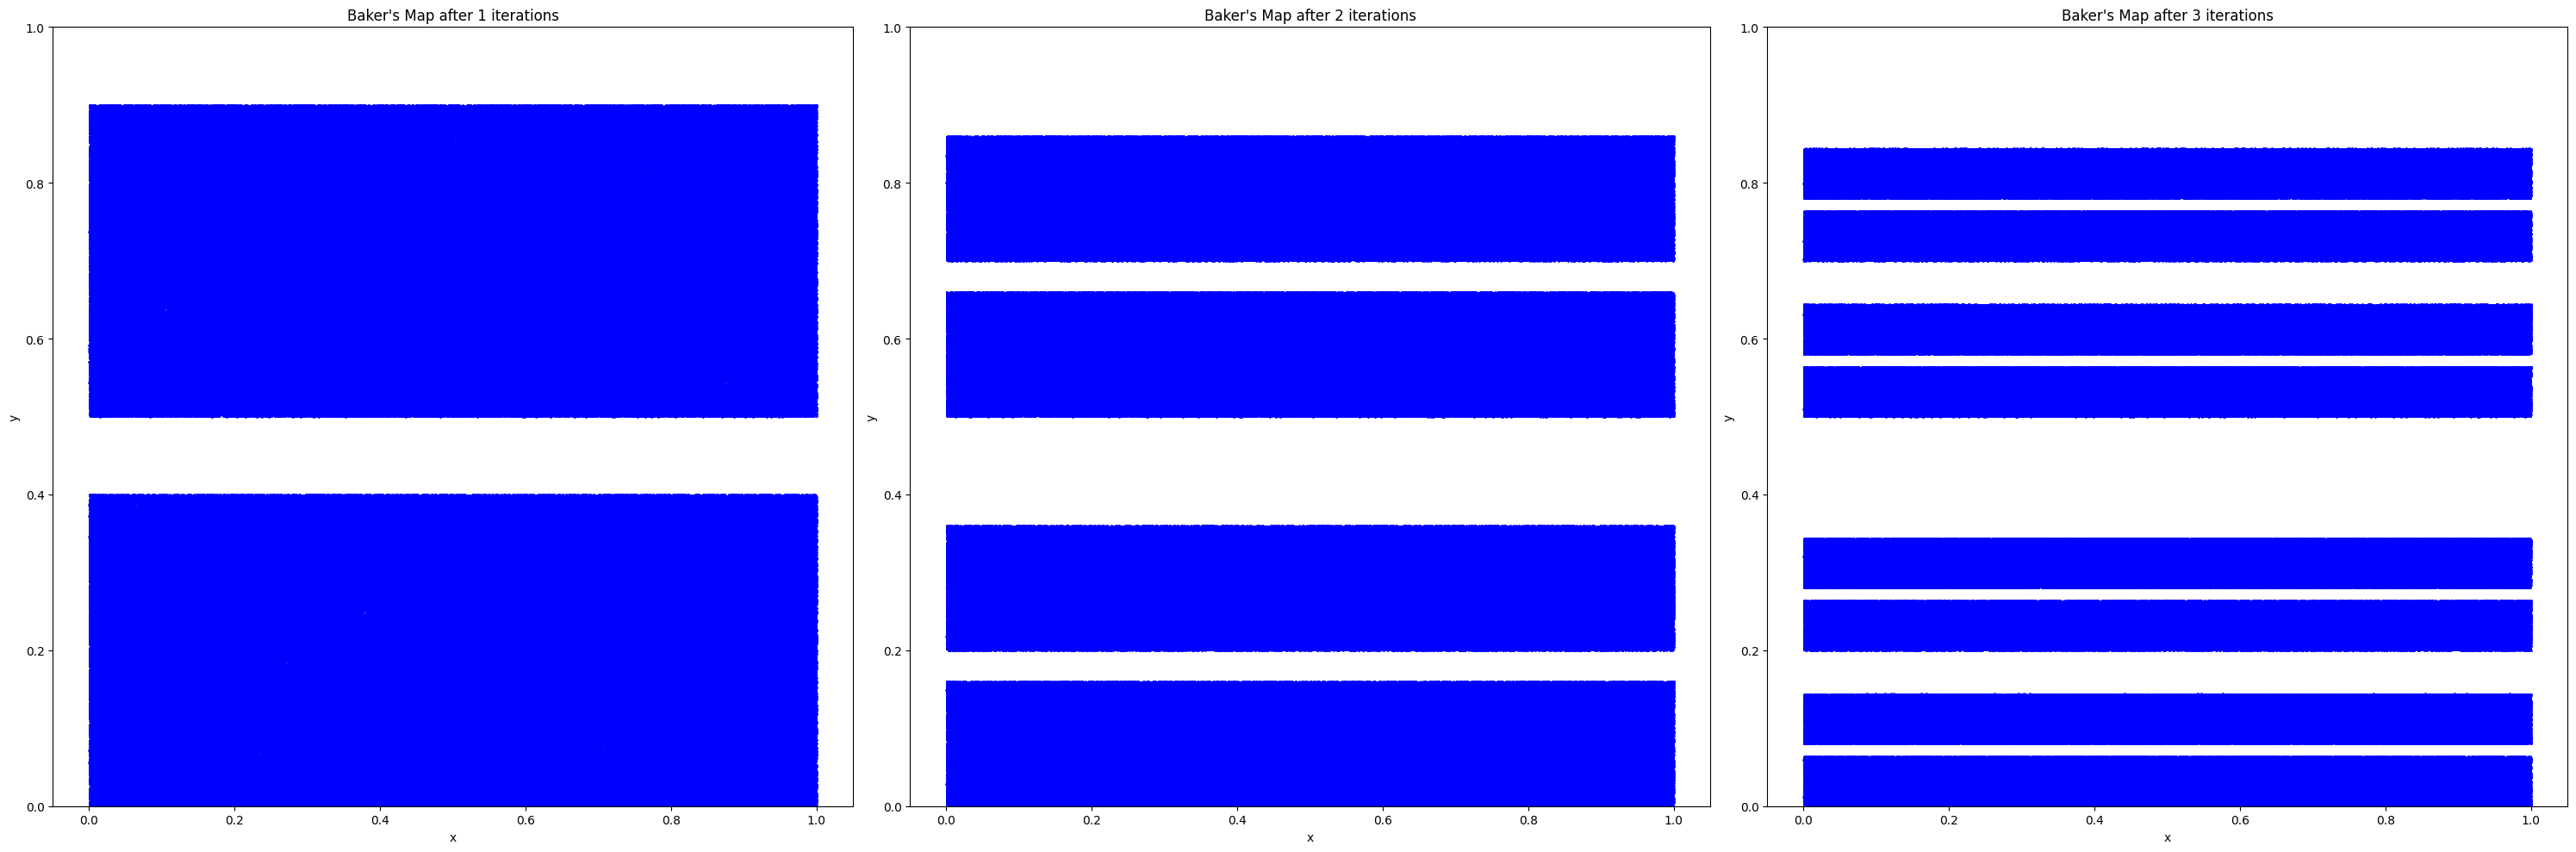

In [24]:
num_points = 1000000
points = np.random.rand(num_points, 2)
a = 0.4
iterations = [1,2,3]

fig, ax = plt.subplots(1, len(iterations), figsize=(30, 10))
for i, iterations in enumerate(iterations):
    x_vals, y_vals = iterate_bakers_map(iterations, a, points)
    ax[i].scatter(x_vals, y_vals, s=1, color='blue')
    ax[i].set_title("Baker's Map after {} iterations".format(iterations))
    ax[i].set_ylim(0,1)
    ax[i].set_xlabel('x')
    ax[i].set_ylabel('y')
plt.tight_layout()
plt.show()

Study the baker’s map on a computer for the case $a = \frac{1}{2}.$                                                              
Starting from a random initial condition, plot the first ten iterates and label them.

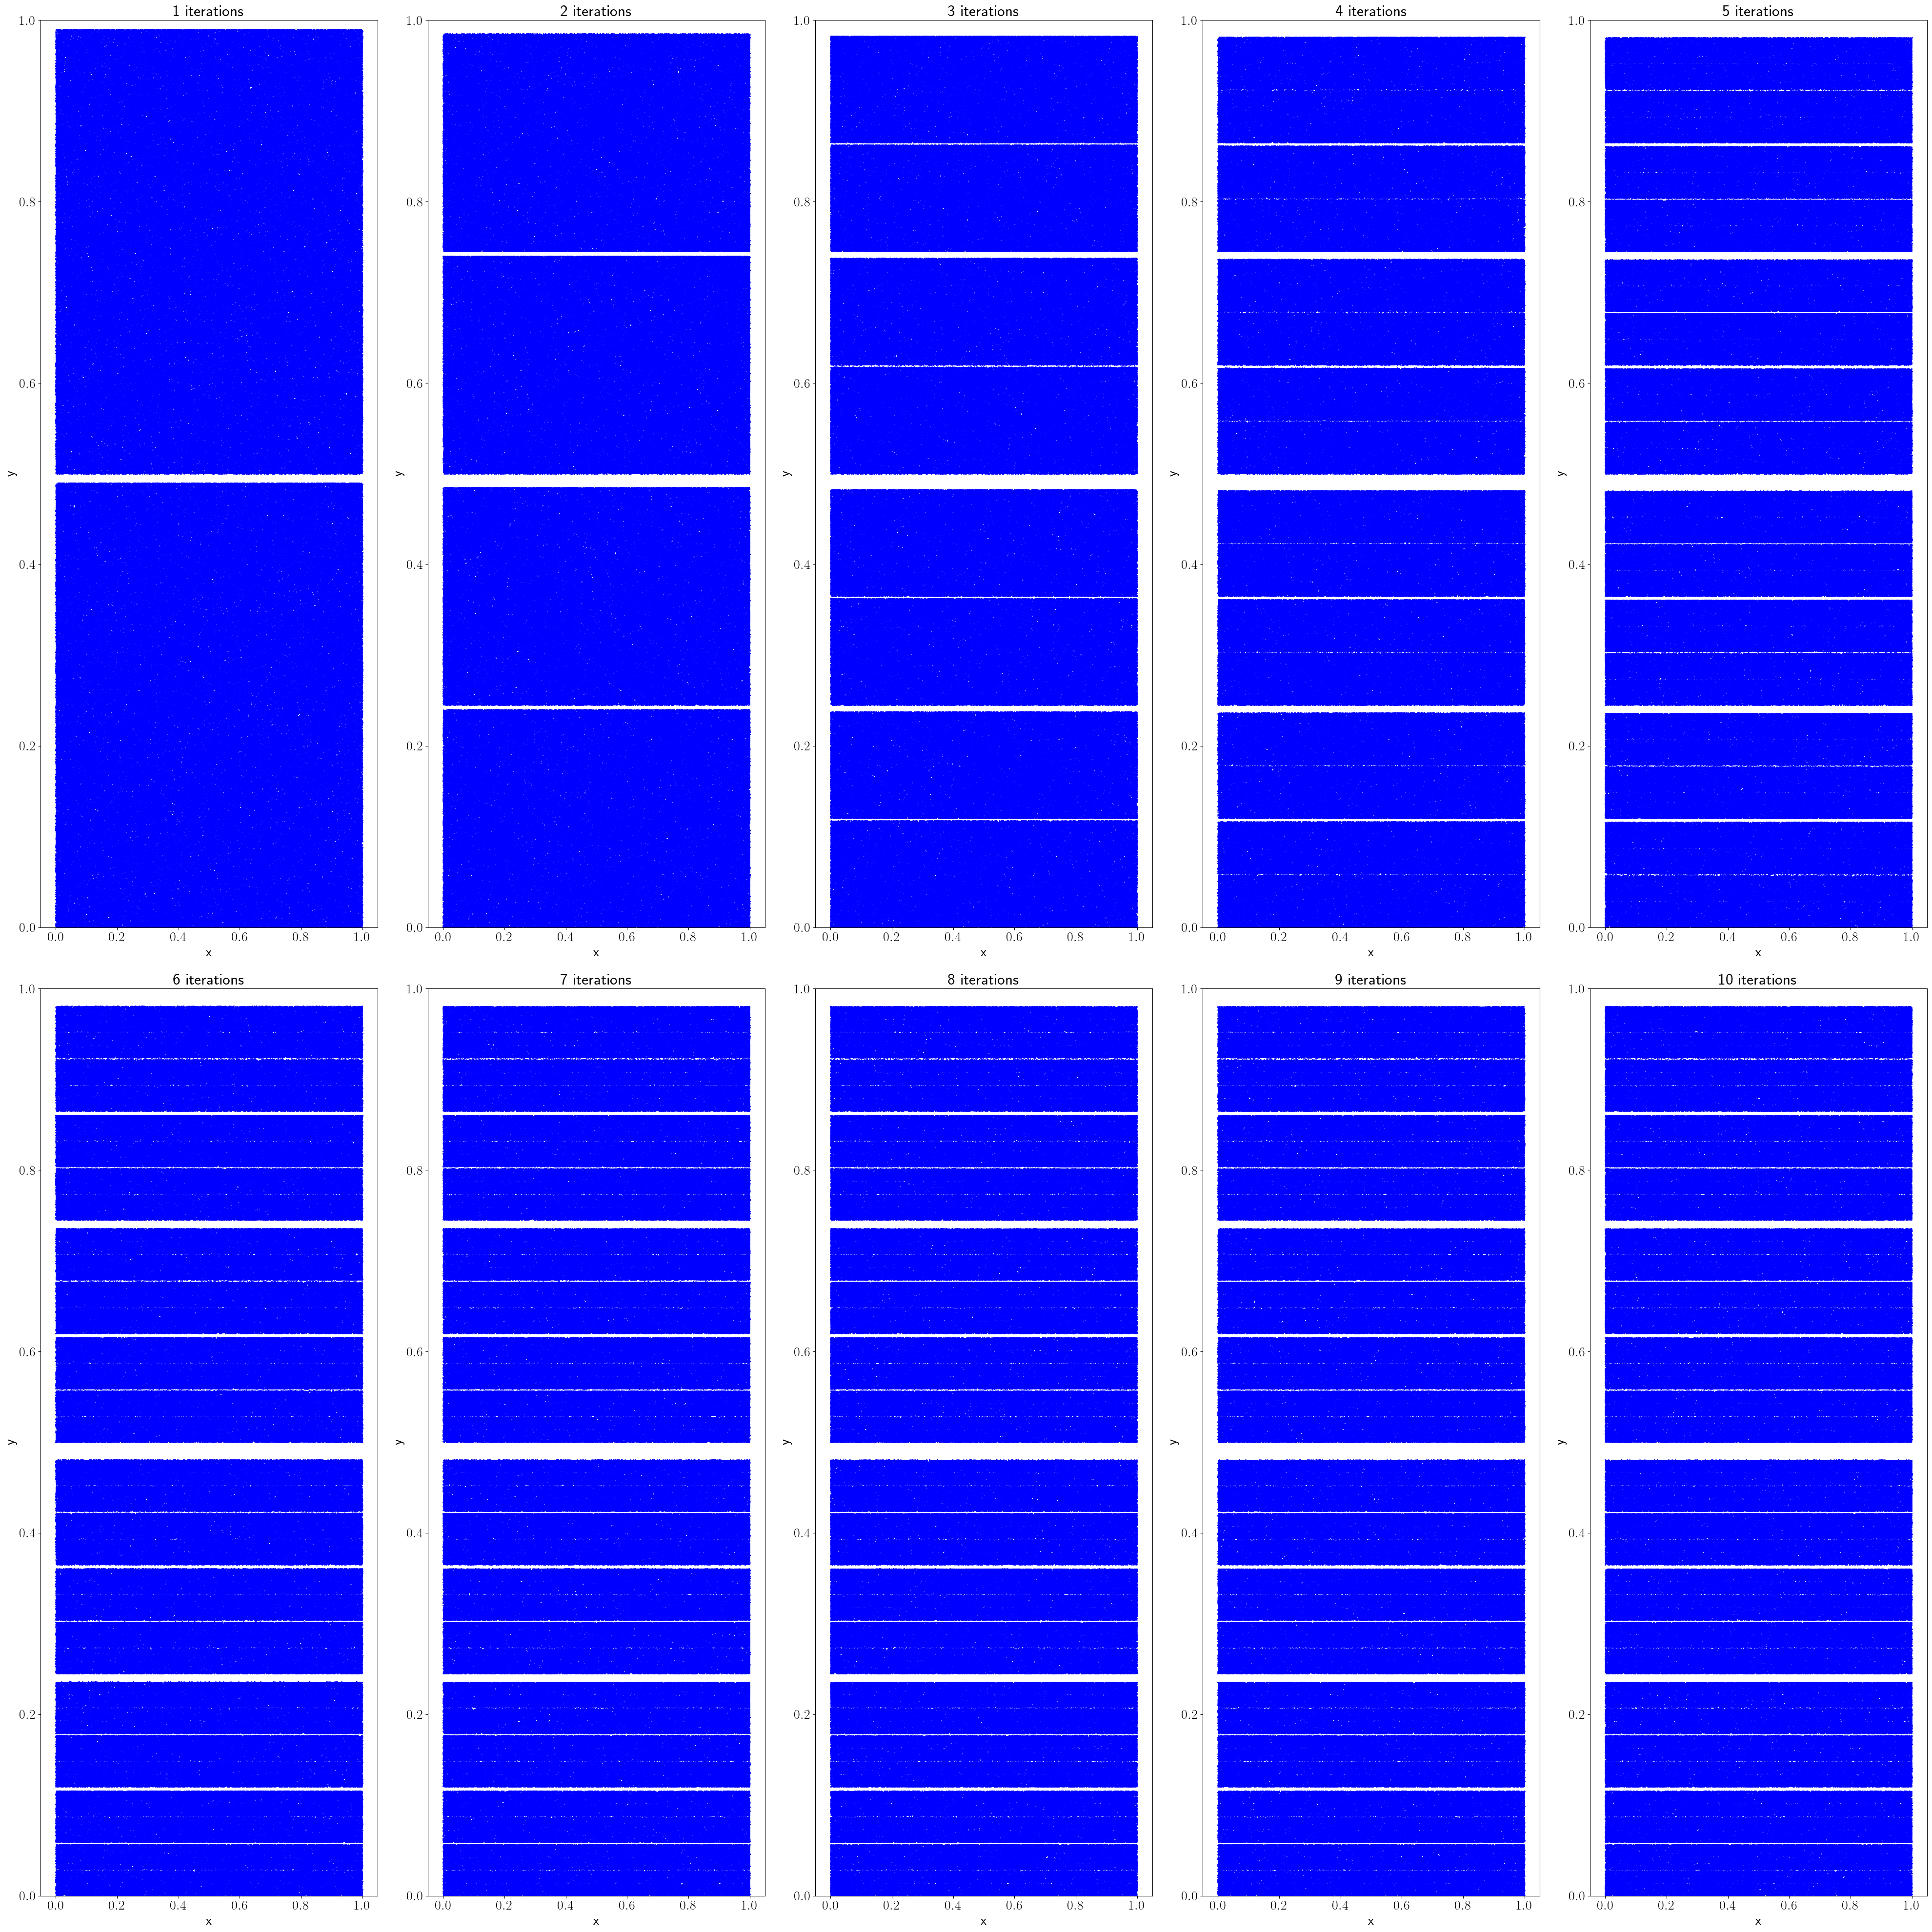

In [12]:
num_points = 1000000
points = np.random.rand(num_points, 2)
a = 0.49
iterations_list = [1,2,3,4,5,6,7,8,9,10]

fig, axes = plt.subplots(2, 5, figsize=(40, 40))
for i, iterations in enumerate(iterations_list):
    x_transformed, y_transformed = iterate_bakers_map(iterations, a, points)
    ax = axes[i // 5, i % 5]  # Access the correct subplot
    ax.scatter(x_transformed, y_transformed, s=1, color='blue')
    ax.set_title(f"{iterations} iterations")
    ax.set_ylim(0, 1)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
plt.tight_layout()
plt.show()

In [4]:
def lyapunov_exponent(point, delta=1e-8, a=0.4, num_steps=50):
    x1, y1 = point
    x2, y2 = x1 + delta, y1
    
    dist_sum = 0.0
    for _ in range(num_steps):
        x1, y1 = bakers_map(np.array([[x1, y1]]), a)[0]
        x2, y2 = bakers_map(np.array([[x2, y2]]), a)[0]
        
        d = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        if d == 0: d = 1e-12  # prevent log(0)
        dist_sum += np.log(abs(d / delta))
        
        # Renormalize the separation
        dx, dy = x2 - x1, y2 - y1
        norm = np.sqrt(dx**2 + dy**2)
        x2, y2 = x1 + delta * dx / norm, y1 + delta * dy / norm
    
    return dist_sum / num_steps

# Example
lyap = lyapunov_exponent((0.1, 0.1), a=0.4)
print("Lyapunov exponent ≈", lyap)


Lyapunov exponent ≈ 0.693147182698124


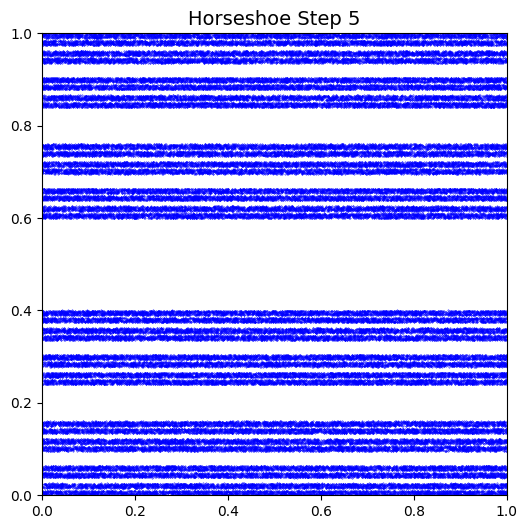

In [15]:
from scipy.integrate import quad
import matplotlib.animation as animation
from IPython.display import clear_output, display, HTML

def bakers_map(points, a):
    x, y = points[:, 0], points[:, 1]
    left = x <= 0.5
    right = ~left

    x_new = np.empty_like(x)
    y_new = np.empty_like(y)

    x_new[left] = 2 * x[left]
    y_new[left] = a * y[left]

    x_new[right] = 2 * x[right] - 1
    y_new[right] = a * y[right] + (1 - a)

    return np.column_stack((x_new, y_new))

# Create an initial dense grid representing the unit square
num_points = 100_000
points = np.random.rand(num_points, 2)
a = 0.4  # Use 0.5 to preserve area (canonical horseshoe behavior)
max_iterations = 5

# Set up the plot
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(points[:, 0], points[:, 1], s=0.1, color='blue')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Baker's Map Horseshoe Analogy", fontsize=14)

# Store iterations in a list to avoid recomputing
frames = [points]
for _ in range(max_iterations):
    frames.append(bakers_map(frames[-1], a))

# Animation update function
def update(frame_num):
    sc.set_offsets(frames[frame_num])
    ax.set_title(f"Horseshoe Step {frame_num}", fontsize=14)
    return sc,

# Create the animation
ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=800, blit=True)
mg_path="bakers map.gif"
ani.save(mg_path, writer=animation.PillowWriter(fps=20))
#display(HTML(f'<img src="{mg_path}" width="600">'))
clear_output(wait=True)
HTML(ani.to_jshtml())

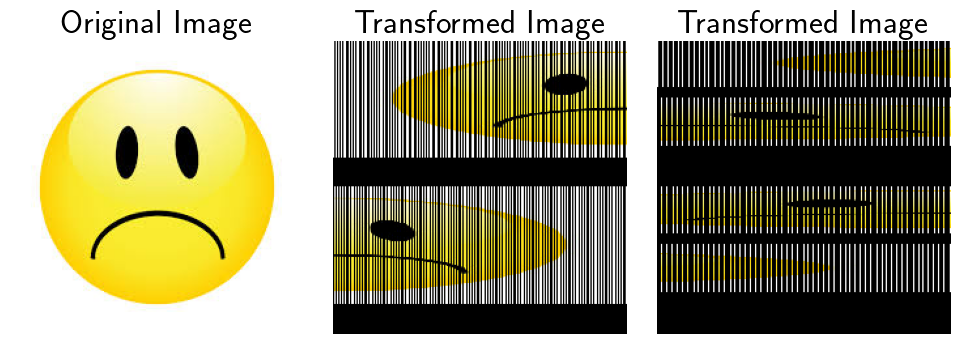

In [11]:
def transform_image(image_path, a, iterations):
    # Load the image
    image = Image.open(image_path)
    image = image.convert('RGB')  # Ensure the image is in RGB format
    width, height = image.size
    
    # Normalize the pixel coordinates to the unit square
    x_vals, y_vals = np.meshgrid(np.linspace(0, 1, width), np.linspace(0, 1, height))
    x_vals = x_vals.flatten()
    y_vals = y_vals.flatten()
    
    # Apply the Baker's Map iterations
    for _ in range(iterations):
        new_x_vals, new_y_vals = [], []
        for x, y in zip(x_vals, y_vals):
            x_new, y_new = bakers_map(x, y, a)
            new_x_vals.append(x_new)
            new_y_vals.append(y_new)
        x_vals = np.array(new_x_vals)
        y_vals = np.array(new_y_vals)
    
    # Map the transformed coordinates back to pixel values
    x_vals = (x_vals * (width - 1)).astype(int)
    y_vals = (y_vals * (height - 1)).astype(int)
    
    # Create the transformed image
    transformed_image = Image.new('RGB', (width, height))
    pixels = transformed_image.load()
    
    original_pixels = image.load()
    for i in range(width):
        for j in range(height):
            pixels[x_vals[j * width + i], y_vals[j * width + i]] = original_pixels[i, j]
    
    return transformed_image

# Parameters for the Baker's map
a = 0.4
iterations = [1, 2]
image_path = 'sad.jpeg'

# Plot the original and transformed images
fig, axs = plt.subplots(1, len(iterations)+1, figsize=(10, 4))

# Original image
original_image = Image.open(image_path)
axs[0].imshow(original_image)
axs[0].axis('off')
axs[0].set_title('Original Image')

# Transformed image
for i, itr in enumerate(iterations):
    transformed_image = transform_image(image_path, a, itr)
    axs[i+1].imshow(transformed_image)
    axs[i+1].axis('off')
    axs[i+1].set_title('Transformed Image')

plt.tight_layout()
plt.show()

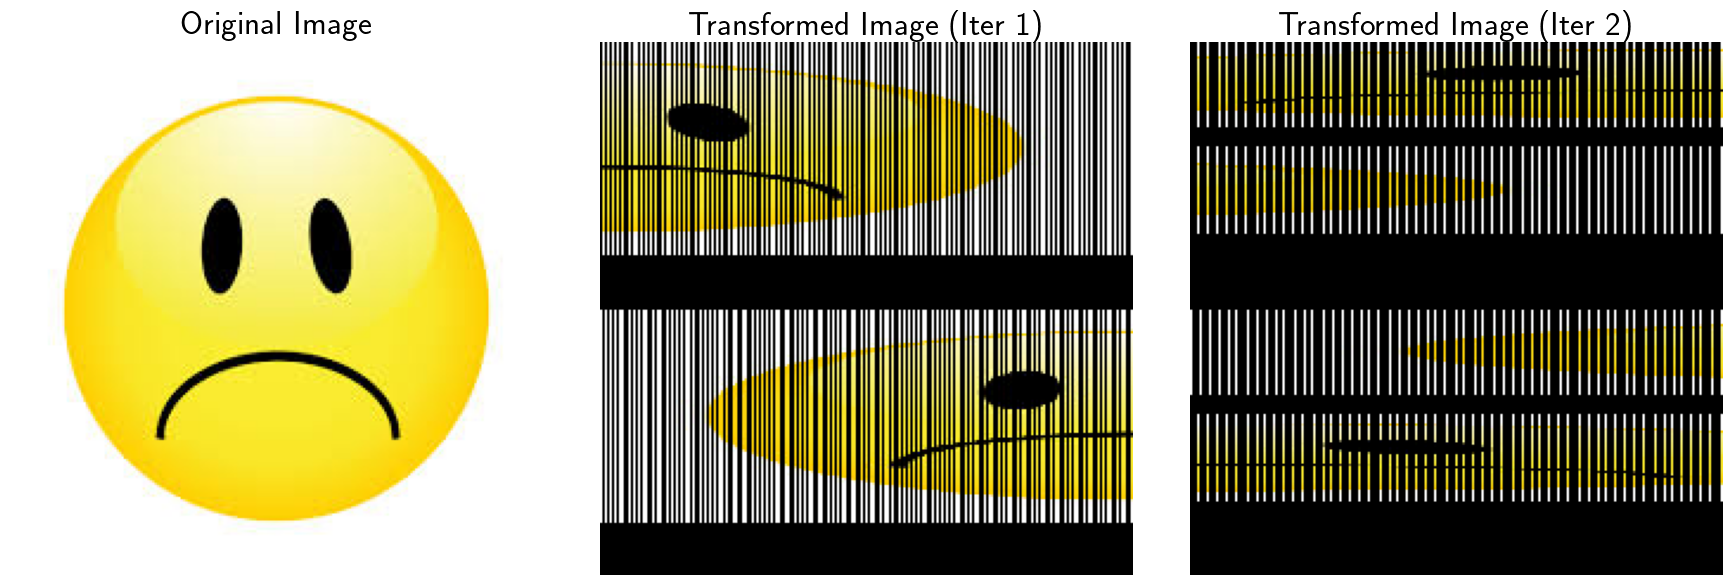

In [12]:
def transform_image(image_path, a, iterations):
    # Load the image
    image = Image.open(image_path)
    image = image.convert('RGB')  # Ensure the image is in RGB format
    width, height = image.size
    
    # Normalize the pixel coordinates to the unit square
    x_vals, y_vals = np.meshgrid(np.linspace(0, 1, width), np.linspace(0, 1, height))
    x_vals = x_vals.flatten()
    y_vals = y_vals.flatten()
    
    # Apply the Baker's Map iterations
    for _ in range(iterations):
        new_x_vals, new_y_vals = [], []
        for x, y in zip(x_vals, y_vals):
            x_new, y_new = bakers_map(x, y, a)
            new_x_vals.append(x_new)
            new_y_vals.append(y_new)
        x_vals = np.array(new_x_vals)
        y_vals = np.array(new_y_vals)
    
    # Adjust the positions
    x_vals = np.clip(x_vals * (width - 1), 0, width - 1).astype(int)
    y_vals = np.clip(y_vals * (height - 1), 0, height - 1).astype(int)
    
    # Create the transformed image
    transformed_image = Image.new('RGB', (width, height))
    pixels = transformed_image.load()
    
    # Assign pixels based on transformed coordinates
    original_pixels = image.load()
    for i in range(len(x_vals)):
        pixels[x_vals[i], y_vals[i]] = original_pixels[i % width, i // width]
    
    # Convert transformed image to numpy array for further processing
    transformed_array = np.array(transformed_image)
    
    # Split into top and bottom slices
    top_slice = transformed_array[:height // 2]
    bottom_slice = transformed_array[height // 2:]
    
    # Swap slices
    swapped_image_array = np.vstack((bottom_slice, top_slice))
    
    # Convert back to image
    swapped_image = Image.fromarray(swapped_image_array)
    
    return swapped_image

# Parameters for the Baker's map
a = 0.4
iterations = [1, 2]
image_path = 'sad.jpeg'

# Plot the original and transformed images
fig, axs = plt.subplots(1, len(iterations) + 1, figsize=(18, 6))

# Original image
original_image = Image.open(image_path)
axs[0].imshow(original_image)
axs[0].axis('off')
axs[0].set_title('Original Image')

# Transformed images
for i, itr in enumerate(iterations):
    transformed_image = transform_image(image_path, a, itr)
    axs[i + 1].imshow(transformed_image)
    axs[i + 1].axis('off')
    axs[i + 1].set_title(f'Transformed Image (Iter {itr})')

plt.tight_layout()
plt.show()

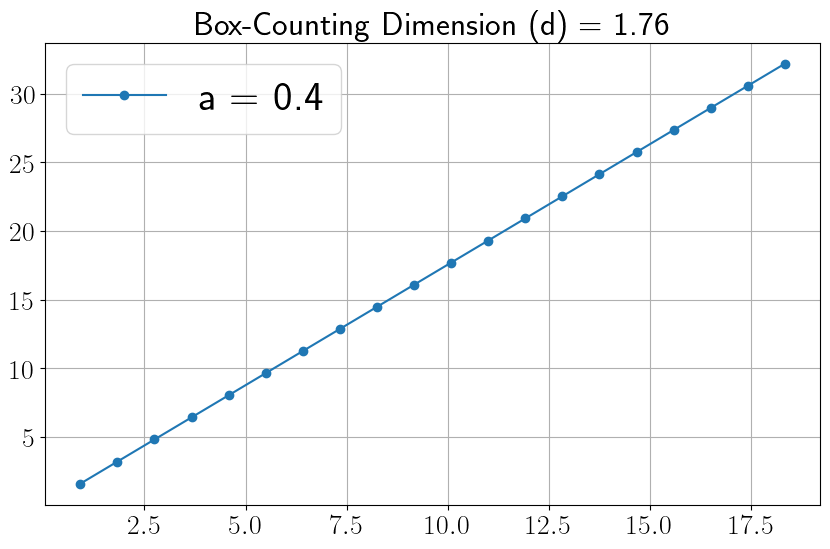

Calculated Box-Counting Dimension: 1.76


In [13]:
def calculate_box_counting_dimension(a, max_n):
    """Calculate the box-counting dimension of the Baker's map attractor."""
    n_values = np.arange(1, max_n + 1)
    epsilon_values = a ** n_values
    N_values = (a / 2) ** (-n_values)
    
    # Calculate dimension
    log_epsilon = np.log(1 / epsilon_values)
    log_N = np.log(N_values)
    dimension = 1 + np.log(1 / 2) / np.log(a)
    
    return n_values, log_epsilon, log_N, dimension

# Parameters
a = 0.4
max_n = 20

# Compute
n_values, log_epsilon, log_N, dimension = calculate_box_counting_dimension(a, max_n)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(log_epsilon, log_N, 'o-', label=f'a = {a}')

plt.title(f'Box-Counting Dimension (d) = {dimension:.2f}')
plt.legend()
plt.grid(True)
plt.show()

print(f'Calculated Box-Counting Dimension: {dimension:.2f}')